### Economic Clustering

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

In [27]:
df = pd.read_excel("economic_variables.xlsx", dtype={"FIPS": str})
df.head()

,FIPS,Poverty_Rate,Household_Income,County_Name,Population_2020,RUCC_2023,Establishment_Count,Quarterly_Wages,Average_Weekly_Wage
0,01001,12.9,78840,Autauga County,58805,2,1185,169682330,996
1,01003,10.5,82519,Baldwin County,231767,3,9354,1146658058,992
2,01005,28.1,45902,Barbour County,25223,6,599,87898192,872
3,01007,21.6,60359,Bibb County,22293,1,461,64817129,1027
4,01009,11.7,69371,Blount County,59134,1,998,107736673,891


#### EDA

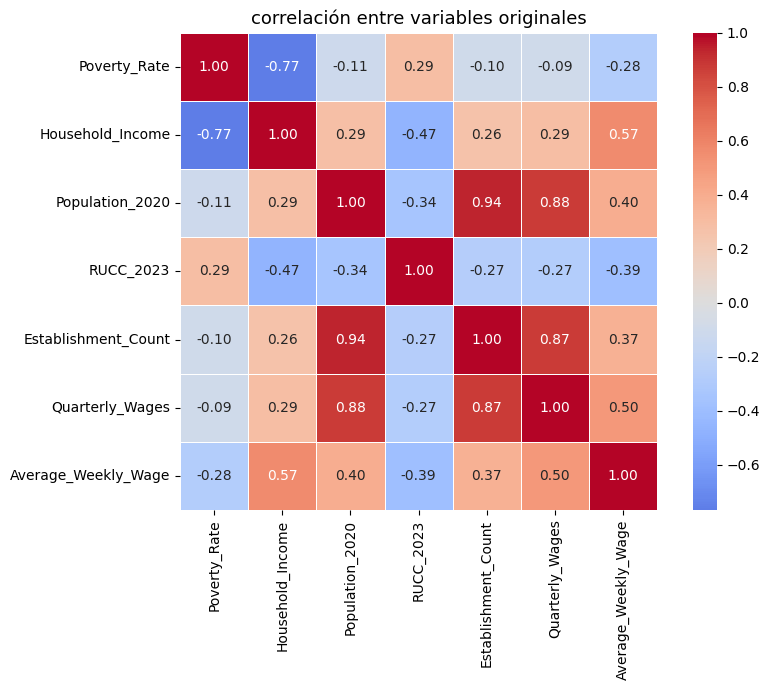

In [28]:
vars_original = ['Poverty_Rate', 'Household_Income', 'Population_2020', 'RUCC_2023',
                  'Establishment_Count', 'Quarterly_Wages', 'Average_Weekly_Wage']

plt.figure(figsize=(9, 7))
sns.heatmap(df[vars_original].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('correlación entre variables originales', fontsize=13)
plt.tight_layout()
plt.show()

In [29]:
# transformación log
df['Log_Establishments'] = np.log1p(df['Establishment_Count'])
df['Log_Average_Weekly_Wage'] = np.log1p(df['Average_Weekly_Wage'])

# vulnerability_index
mms = MinMaxScaler()
temp = mms.fit_transform(df[['Poverty_Rate', 'RUCC_2023']])
df['vulnerability_index'] = temp[:, 0] * 0.65 + temp[:, 1] * 0.35

variables = ['Poverty_Rate', 'Household_Income', 'RUCC_2023',
             'Log_Average_Weekly_Wage', 'Log_Establishments', 'vulnerability_index']

df[variables].describe().round(3)

,Poverty_Rate,Household_Income,RUCC_2023,Log_Average_Weekly_Wage,Log_Establishments,vulnerability_index
count,3143.000,3143.000,3143.00,3143.000,3143.000,3143.000
mean,14.108,69497.632,5.25,6.940,6.742,0.315
std,5.437,17233.425,2.93,0.184,1.480,0.162
min,3.800,34802.000,1.00,6.415,2.398,0.005
25%,10.350,58374.000,2.00,6.820,5.704,0.175
50%,13.200,66757.000,6.00,6.916,6.551,0.334
75%,16.800,77138.000,8.00,7.031,7.580,0.441
max,55.700,177457.000,9.00,8.230,13.293,1.000


In [30]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[variables])

# reducción de dimensionalidad
# opción a: PCA (interpretable, preserva distancias globales)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
df_pca = pca.fit_transform(df_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=RANDOM_STATE).fit(df_pca)

df['cluster'] = kmeans_pca.labels_

#### Profiles

In [31]:
print(df['cluster'].value_counts().sort_index())
df.groupby('cluster')[variables].mean().round(2)

cluster
0     713
1    1051
2    1379
Name: count, dtype: int64


,Poverty_Rate,Household_Income,RUCC_2023,Log_Average_Weekly_Wage,Log_Establishments,vulnerability_index
cluster,,,,,,
0,21.15,51799.85,7.44,6.81,5.74,0.50
1,10.88,83992.05,2.07,7.07,8.17,0.14
2,12.93,67601.25,6.55,6.91,6.18,0.36


In [35]:
# asignar labels a los clusters según su interpretación
cluster_labels = {
    0: 'low economic stability',
    1: 'high economic stability',
    2: 'medium economic stability'
}

df['cluster'] = df['cluster'].map(cluster_labels)

<Axes: >

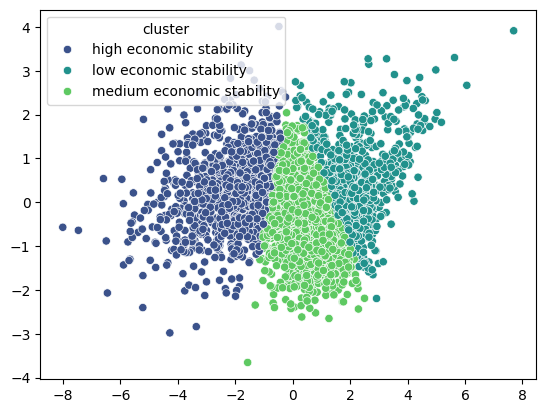

In [37]:
# quiero ver los clusters en un scatterplot de las dos dimensiones principales
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df['cluster'], palette='viridis')

<Axes: xlabel='Household_Income', ylabel='vulnerability_index'>

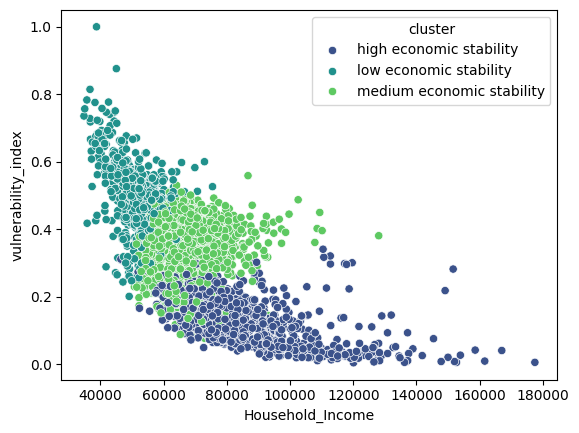

In [38]:
# ahora ver los clusters en un scatterplot de las dos variables más importantes según PCA
pca_components = pca.components_
important_vars = [variables[i] for i in np.argsort(np.abs(pca_components[0]))[-2:]]  # las dos variables más importantes para PC1
sns.scatterplot(x=df[important_vars[0]], y=df[important_vars[1]], hue=df['cluster'], palette='viridis')